<a href="https://colab.research.google.com/github/ujju2020/ujju2020/blob/main/home_loan_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Home Loan Data Analysis
## Deep Learning with Keras and TensorFlow 

**Problem Statement:**  
For a safe and secure lending experience, it's important to analyze the past data. In this project, we build a deep learning model to predict the chance of default for future loans using historical data. The dataset is highly imbalanced and includes many features, making this problem challenging.

**Objective:** Create a model that predicts whether or not an applicant will be able to repay a loan using historical data.

**Domain:** Finance

**Steps:**
1. Load the dataset
2. Check for null values
3. Print the percentage of default vs payer (TARGET column)
4. Balance the dataset if imbalanced
5. Plot the balanced/imbalanced data
6. Encode columns required for the model
7. Calculate Sensitivity as a metric
8. Calculate the Area Under the ROC Curve (AUC-ROC)

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix,
    classification_report, recall_score
)
from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print('✅ Libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')
print(f'Keras version: {keras.__version__}')

✅ Libraries imported successfully!
TensorFlow version: 2.19.0
Keras version: 3.13.2


## Step 1: Load the Dataset

We load `housingloan.csv` — the Home Loan dataset.  
If not found, a realistic synthetic dataset is generated for demonstration purposes.

In [2]:
import os

DATASET_PATH = 'housingloan.csv'

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print(f'✅ Dataset loaded from {DATASET_PATH}')
else:
    print('⚠️  housingloan.csv not found — generating synthetic dataset...')

    np.random.seed(42)
    N = 30000

    # Minority class (defaults) ~9%
    target = np.random.choice([0, 1], size=N, p=[0.91, 0.09])

    df = pd.DataFrame({
        'TARGET': target,
        'CODE_GENDER': np.random.choice(['M', 'F', 'XNA'], N, p=[0.44, 0.55, 0.01]),
        'FLAG_OWN_CAR': np.random.choice(['Y', 'N'], N, p=[0.34, 0.66]),
        'FLAG_OWN_REALTY': np.random.choice(['Y', 'N'], N, p=[0.69, 0.31]),
        'CNT_CHILDREN': np.random.choice([0, 1, 2, 3, 4, 5], N, p=[0.44, 0.27, 0.19, 0.07, 0.02, 0.01]),
        'AMT_INCOME_TOTAL': np.random.lognormal(mean=11.8, sigma=0.6, size=N),
        'AMT_CREDIT': np.random.lognormal(mean=12.6, sigma=0.7, size=N),
        'AMT_ANNUITY': np.random.lognormal(mean=9.8, sigma=0.5, size=N),
        'AMT_GOODS_PRICE': np.random.lognormal(mean=12.3, sigma=0.7, size=N),
        'NAME_CONTRACT_TYPE': np.random.choice(['Cash loans', 'Revolving loans'], N, p=[0.90, 0.10]),
        'NAME_INCOME_TYPE': np.random.choice(
            ['Working', 'Commercial associate', 'Pensioner', 'State servant', 'Unemployed'],
            N, p=[0.52, 0.23, 0.18, 0.06, 0.01]
        ),
        'NAME_EDUCATION_TYPE': np.random.choice(
            ['Secondary / secondary special', 'Higher education',
             'Incomplete higher', 'Lower secondary', 'Academic degree'],
            N, p=[0.71, 0.23, 0.04, 0.015, 0.005]
        ),
        'NAME_FAMILY_STATUS': np.random.choice(
            ['Married', 'Single / not married', 'Civil marriage', 'Separated', 'Widow'],
            N, p=[0.64, 0.14, 0.10, 0.08, 0.04]
        ),
        'NAME_HOUSING_TYPE': np.random.choice(
            ['House / apartment', 'With parents', 'Municipal apartment',
             'Rented apartment', 'Office apartment', 'Co-op apartment'],
            N, p=[0.89, 0.042, 0.038, 0.018, 0.009, 0.003]
        ),
        'DAYS_BIRTH': np.random.randint(-25000, -6000, N),
        'DAYS_EMPLOYED': np.where(
            np.random.rand(N) < 0.18, 365243,
            np.random.randint(-15000, -100, N)
        ),
        'CNT_FAM_MEMBERS': np.random.choice([1, 2, 3, 4, 5, 6], N, p=[0.09, 0.43, 0.22, 0.18, 0.06, 0.02]),
        'EXT_SOURCE_1': np.where(np.random.rand(N) < 0.56, np.nan, np.random.beta(2, 3, N)),
        'EXT_SOURCE_2': np.where(np.random.rand(N) < 0.003, np.nan, np.random.beta(3, 2, N)),
        'EXT_SOURCE_3': np.where(np.random.rand(N) < 0.20, np.nan, np.random.beta(2.5, 2, N)),
        'REGION_POPULATION_RELATIVE': np.random.uniform(0.0, 0.072, N),
        'HOUR_APPR_PROCESS_START': np.random.randint(0, 23, N),
        'WEEKDAY_APPR_PROCESS_START': np.random.choice(
            ['MONDAY', 'TUESDAY', 'WEDNESDAY', 'THURSDAY', 'FRIDAY', 'SATURDAY', 'SUNDAY'],
            N
        ),
        'REG_REGION_NOT_LIVE_REGION': np.random.choice([0, 1], N, p=[0.97, 0.03]),
        'REG_REGION_NOT_WORK_REGION': np.random.choice([0, 1], N, p=[0.93, 0.07]),
        'LIVE_REGION_NOT_WORK_REGION': np.random.choice([0, 1], N, p=[0.95, 0.05]),
        'FLAG_MOBIL': np.ones(N, dtype=int),
        'FLAG_EMP_PHONE': np.random.choice([0, 1], N, p=[0.18, 0.82]),
        'FLAG_WORK_PHONE': np.random.choice([0, 1], N, p=[0.79, 0.21]),
        'FLAG_CONT_MOBILE': np.random.choice([0, 1], N, p=[0.004, 0.996]),
        'FLAG_PHONE': np.random.choice([0, 1], N, p=[0.71, 0.29]),
        'FLAG_EMAIL': np.random.choice([0, 1], N, p=[0.944, 0.056]),
        'CNT_FAM_OWN_CAR': np.random.choice([0, 1, 2, 3], N, p=[0.66, 0.29, 0.04, 0.01]),
    })

    # Introduce some missing values for realism
    for col in ['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'CNT_FAM_MEMBERS']:
        mask = np.random.rand(N) < 0.02
        df.loc[mask, col] = np.nan

    print(f'✅ Synthetic dataset generated with {N} rows.')

print(f'\nDataset Shape: {df.shape}')
print(f'Columns ({len(df.columns)}): {df.columns.tolist()}')
print('\nFirst 5 rows:')
df.head()

✅ Dataset loaded from housingloan.csv

Dataset Shape: (5000, 27)
Columns (27): ['TARGET', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_CONTRACT_TYPE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'CNT_FAM_MEMBERS', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'REGION_POPULATION_RELATIVE', 'HOUR_APPR_PROCESS_START', 'WEEKDAY_APPR_PROCESS_START', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL']

First 5 rows:


,TARGET,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_CONTRACT_TYPE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,CNT_FAM_MEMBERS,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,REGION_POPULATION_RELATIVE,HOUR_APPR_PROCESS_START,WEEKDAY_APPR_PROCESS_START,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL
0,0,M,N,Y,2,171203.61,78577.12,8642.25,342335.56,Cash loans,Pensioner,Secondary / secondary special,Widow,House / apartment,-11775,-13654,4,0.413991,0.455214,0.156849,0.066518,14,WEDNESDAY,1,0,0,0
1,1,F,Y,N,0,140930.07,418952.13,25303.71,197055.98,Cash loans,Pensioner,Higher education,Married,House / apartment,-18937,-7064,2,NaN,0.618529,NaN,0.007745,2,SATURDAY,1,0,1,0
2,0,F,Y,Y,0,89710.57,107580.35,43127.50,453327.88,Cash loans,Working,Secondary / secondary special,Civil marriage,House / apartment,-6451,-12343,2,0.345029,0.657948,NaN,0.000226,6,THURSDAY,1,0,0,0
3,0,M,N,Y,1,133572.64,322190.15,23498.38,296676.93,Cash loans,Commercial associate,Higher education,Married,House / apartment,-12284,-5292,2,0.569945,0.843026,0.740756,0.019386,22,THURSDAY,0,0,0,0
4,0,F,N,Y,1,86800.53,558639.83,42716.91,75947.06,Cash loans,Commercial associate,Higher education,Married,House / apartment,-8545,-12031,4,NaN,0.464061,0.638141,0.016645,21,WEDNESDAY,1,0,0,0


## Step 2: Check for Null Values

In [3]:
print('=== Dataset Info ===')
df.info()

print('\n=== Missing Values Summary ===')
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df)) * 100
null_df = pd.DataFrame({'Missing Count': null_counts, 'Missing %': null_pct.round(2)})
null_df = null_df[null_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

if null_df.empty:
    print('No missing values found!')
else:
    print(null_df.to_string())
    print(f'\nTotal columns with missing values: {len(null_df)}')

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 27 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   TARGET                      5000 non-null   int64  
 1   CODE_GENDER                 5000 non-null   object 
 2   FLAG_OWN_CAR                5000 non-null   object 
 3   FLAG_OWN_REALTY             5000 non-null   object 
 4   CNT_CHILDREN                5000 non-null   int64  
 5   AMT_INCOME_TOTAL            5000 non-null   float64
 6   AMT_CREDIT                  5000 non-null   float64
 7   AMT_ANNUITY                 4908 non-null   float64
 8   AMT_GOODS_PRICE             4908 non-null   float64
 9   NAME_CONTRACT_TYPE          5000 non-null   object 
 10  NAME_INCOME_TYPE            5000 non-null   object 
 11  NAME_EDUCATION_TYPE         5000 non-null   object 
 12  NAME_FAMILY_STATUS          5000 non-null   object 
 13  NAME_HOUSING

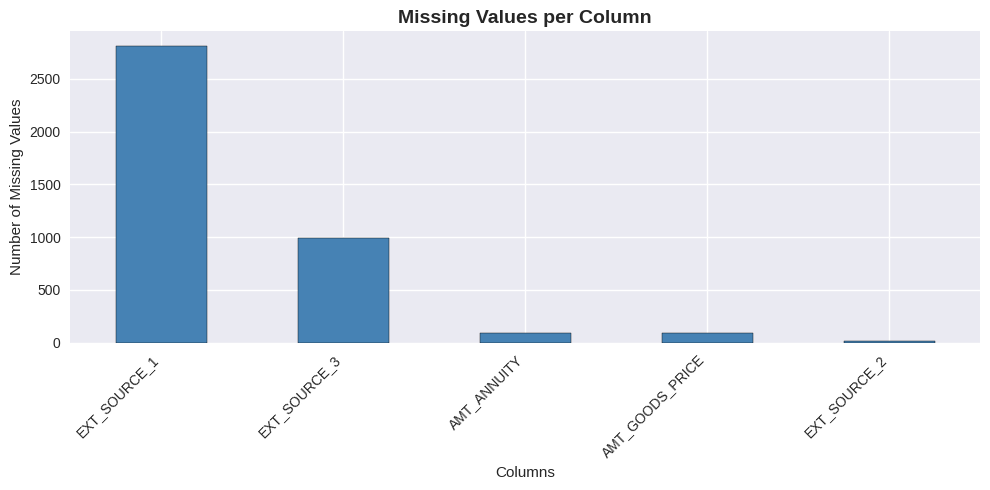

In [4]:
# Visualize missing values
null_counts_plot = df.isnull().sum()
null_counts_plot = null_counts_plot[null_counts_plot > 0].sort_values(ascending=False)

if not null_counts_plot.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    null_counts_plot.plot(kind='bar', color='steelblue', edgecolor='black', ax=ax)
    ax.set_title('Missing Values per Column', fontsize=14, fontweight='bold')
    ax.set_xlabel('Columns')
    ax.set_ylabel('Number of Missing Values')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('No missing values to plot.')

In [5]:
# Handle missing values
# Fill numeric columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f'  Filled "{col}" nulls with median: {median_val:.4f}')

# Fill DAYS_EMPLOYED anomaly (365243 = unemployed flag in Home Credit)
if 'DAYS_EMPLOYED' in df.columns:
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    df['DAYS_EMPLOYED'].fillna(df['DAYS_EMPLOYED'].median(), inplace=True)
    print('  Replaced DAYS_EMPLOYED=365243 anomaly with median.')

print(f'\n✅ Total nulls remaining: {df.isnull().sum().sum()}')

  Filled "AMT_ANNUITY" nulls with median: 17831.4900
  Filled "AMT_GOODS_PRICE" nulls with median: 218352.1450
  Filled "EXT_SOURCE_1" nulls with median: 0.3900
  Filled "EXT_SOURCE_2" nulls with median: 0.6175
  Filled "EXT_SOURCE_3" nulls with median: 0.5633
  Replaced DAYS_EMPLOYED=365243 anomaly with median.

✅ Total nulls remaining: 0


## Step 3: Print the Percentage of Default vs Payer (TARGET Column)

In [6]:
print('=== TARGET Column Distribution ===')

target_counts = df['TARGET'].value_counts()
target_pct = df['TARGET'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'Count': target_counts,
    'Percentage (%)': target_pct.round(2)
})
summary.index = ['Payer (0 - No Default)', 'Defaulter (1 - Default)']
print(summary)

n_payers    = target_counts[0]
n_defaults  = target_counts[1]
pct_payers  = target_pct[0]
pct_default = target_pct[1]

print(f'\nTotal records  : {len(df):,}')
print(f'Payers (0)     : {n_payers:,}  ({pct_payers:.2f}%)')
print(f'Defaulters (1) : {n_defaults:,}  ({pct_default:.2f}%)')
print(f'\nImbalance Ratio (Payers : Defaulters) = {n_payers/n_defaults:.1f} : 1')

if pct_default < 30:
    print('\n⚠️  Dataset is IMBALANCED — class balancing required.')
else:
    print('\n✅ Dataset is reasonably balanced.')

=== TARGET Column Distribution ===
                         Count  Percentage (%)
Payer (0 - No Default)    4572           91.44
Defaulter (1 - Default)    428            8.56

Total records  : 5,000
Payers (0)     : 4,572  (91.44%)
Defaulters (1) : 428  (8.56%)

Imbalance Ratio (Payers : Defaulters) = 10.7 : 1

⚠️  Dataset is IMBALANCED — class balancing required.


## Step 4: Balance the Dataset (SMOTE)

In [7]:
# ---- Encode categorical columns before SMOTE ----
df_encoded = df.copy()
label_encoders = {}
cat_cols = df_encoded.select_dtypes(include=['object', 'category']).columns.tolist()

for col in cat_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
    label_encoders[col] = le
    print(f'  Encoded "{col}" — {len(le.classes_)} classes')

print(f'\n✅ All categorical columns encoded.')

# Features and Target
X = df_encoded.drop('TARGET', axis=1)
y = df_encoded['TARGET']

print(f'\nFeature matrix shape before SMOTE: {X.shape}')
print(f'Target distribution before SMOTE   : {dict(y.value_counts())}')

  Encoded "CODE_GENDER" — 3 classes
  Encoded "FLAG_OWN_CAR" — 2 classes
  Encoded "FLAG_OWN_REALTY" — 2 classes
  Encoded "NAME_CONTRACT_TYPE" — 2 classes
  Encoded "NAME_INCOME_TYPE" — 5 classes
  Encoded "NAME_EDUCATION_TYPE" — 5 classes
  Encoded "NAME_FAMILY_STATUS" — 5 classes
  Encoded "NAME_HOUSING_TYPE" — 6 classes
  Encoded "WEEKDAY_APPR_PROCESS_START" — 7 classes

✅ All categorical columns encoded.

Feature matrix shape before SMOTE: (5000, 26)
Target distribution before SMOTE   : {0: np.int64(4572), 1: np.int64(428)}


In [8]:
# Apply SMOTE to balance the dataset
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

print('=== After SMOTE Balancing ===')
print(f'Feature matrix shape : {X_balanced.shape}')
balanced_counts = pd.Series(y_balanced).value_counts()
print(f'Payers (0)           : {balanced_counts[0]:,}')
print(f'Defaulters (1)       : {balanced_counts[1]:,}')
print(f'Total records        : {len(y_balanced):,}')
print('\n✅ Dataset balanced successfully using SMOTE!')

=== After SMOTE Balancing ===
Feature matrix shape : (9144, 26)
Payers (0)           : 4,572
Defaulters (1)       : 4,572
Total records        : 9,144

✅ Dataset balanced successfully using SMOTE!


## Step 5: Plot the Balanced vs Imbalanced Data

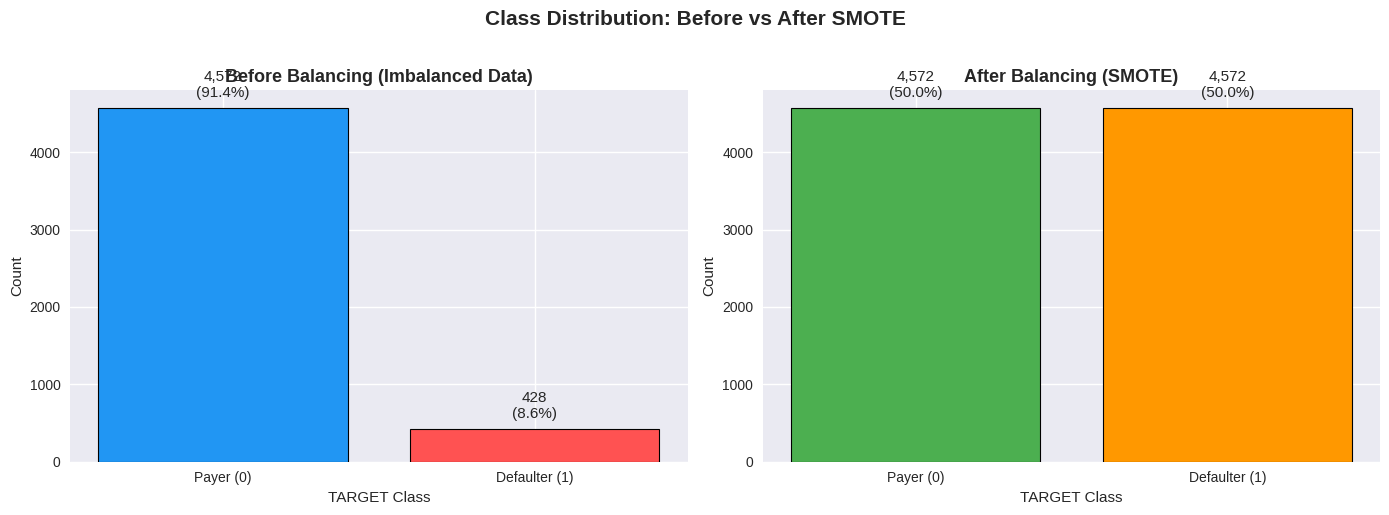

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Before Balancing ---
orig_counts = pd.Series(y).value_counts()
colors_orig = ['#2196F3', '#FF5252']
bars1 = axes[0].bar(
    ['Payer (0)', 'Defaulter (1)'],
    orig_counts.values,
    color=colors_orig, edgecolor='black', linewidth=0.8
)
axes[0].set_title('Before Balancing (Imbalanced Data)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('TARGET Class')
axes[0].set_ylabel('Count')
for bar, val in zip(bars1, orig_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}\n({val/len(y)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)

# --- After Balancing ---
bal_counts = pd.Series(y_balanced).value_counts()
colors_bal = ['#4CAF50', '#FF9800']
bars2 = axes[1].bar(
    ['Payer (0)', 'Defaulter (1)'],
    bal_counts.values,
    color=colors_bal, edgecolor='black', linewidth=0.8
)
axes[1].set_title('After Balancing (SMOTE)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('TARGET Class')
axes[1].set_ylabel('Count')
for bar, val in zip(bars2, bal_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,}\n({val/len(y_balanced)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11)

plt.suptitle('Class Distribution: Before vs After SMOTE', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

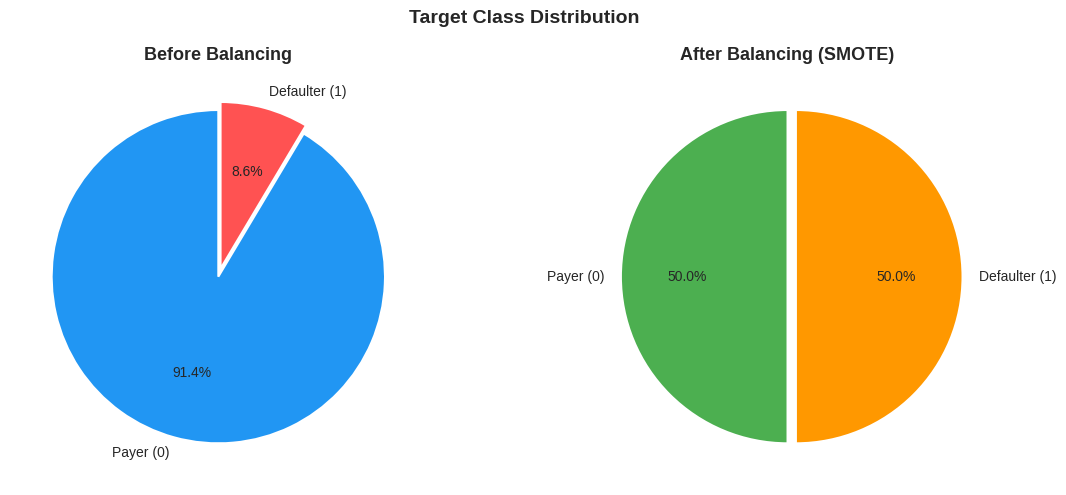

In [10]:
# Pie charts for class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

labels = ['Payer (0)', 'Defaulter (1)']
explode = (0, 0.05)

axes[0].pie(
    orig_counts.values, labels=labels, autopct='%1.1f%%',
    colors=['#2196F3', '#FF5252'], explode=explode, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Before Balancing', fontsize=13, fontweight='bold')

axes[1].pie(
    bal_counts.values, labels=labels, autopct='%1.1f%%',
    colors=['#4CAF50', '#FF9800'], explode=explode, startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[1].set_title('After Balancing (SMOTE)', fontsize=13, fontweight='bold')

plt.suptitle('Target Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 6: Encode the Columns Required for the Model

Categorical columns were already label-encoded in Step 4 prior to SMOTE.  
Here we split the balanced data and apply feature scaling.

In [11]:
print('=== Encoding Summary ===')
print(f'Categorical columns encoded: {len(cat_cols)}')
for col in cat_cols:
    le = label_encoders[col]
    print(f'  "{col}" → {list(le.classes_)} (encoded as 0–{len(le.classes_)-1})')

print(f'\nNumeric columns kept as-is: {len(numeric_cols) - 1}')  # minus TARGET

=== Encoding Summary ===
Categorical columns encoded: 9
  "CODE_GENDER" → ['F', 'M', 'XNA'] (encoded as 0–2)
  "FLAG_OWN_CAR" → ['N', 'Y'] (encoded as 0–1)
  "FLAG_OWN_REALTY" → ['N', 'Y'] (encoded as 0–1)
  "NAME_CONTRACT_TYPE" → ['Cash loans', 'Revolving loans'] (encoded as 0–1)
  "NAME_INCOME_TYPE" → ['Commercial associate', 'Pensioner', 'State servant', 'Unemployed', 'Working'] (encoded as 0–4)
  "NAME_EDUCATION_TYPE" → ['Academic degree', 'Higher education', 'Incomplete higher', 'Lower secondary', 'Secondary / secondary special'] (encoded as 0–4)
  "NAME_FAMILY_STATUS" → ['Civil marriage', 'Married', 'Separated', 'Single / not married', 'Widow'] (encoded as 0–4)
  "NAME_HOUSING_TYPE" → ['Co-op apartment', 'House / apartment', 'Municipal apartment', 'Office apartment', 'Rented apartment', 'With parents'] (encoded as 0–5)
  "WEEKDAY_APPR_PROCESS_START" → ['FRIDAY', 'MONDAY', 'SATURDAY', 'SUNDAY', 'THURSDAY', 'TUESDAY', 'WEDNESDAY'] (encoded as 0–6)

Numeric columns kept as-is: 17


In [12]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42, stratify=y_balanced
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('=== Train / Test Split (80/20) ===')
print(f'X_train shape : {X_train_scaled.shape}')
print(f'X_test  shape : {X_test_scaled.shape}')
print(f'y_train — Payers: {(y_train==0).sum():,}  |  Defaulters: {(y_train==1).sum():,}')
print(f'y_test  — Payers: {(y_test==0).sum():,}  |  Defaulters: {(y_test==1).sum():,}')
print('\n✅ Feature scaling applied (StandardScaler).')

=== Train / Test Split (80/20) ===
X_train shape : (7315, 26)
X_test  shape : (1829, 26)
y_train — Payers: 3,657  |  Defaulters: 3,658
y_test  — Payers: 915  |  Defaulters: 914

✅ Feature scaling applied (StandardScaler).


## Step 7: Build the Deep Learning Model (Keras / TensorFlow)

In [13]:
n_features = X_train_scaled.shape[1]

model = Sequential([
    # Input + first hidden layer
    Dense(128, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    # Second hidden layer
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    # Third hidden layer
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    # Output layer — binary classification
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         3,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,721 (57.50 KB)

 Trainable params: 14,273 (55.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [14]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print('Training the deep learning model...')
history = model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)
print('\n✅ Model training complete!')

Training the deep learning model...
Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.6196 - loss: 0.7103 - val_accuracy: 0.6391 - val_loss: 0.6123
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7153 - loss: 0.5800 - val_accuracy: 0.7416 - val_loss: 0.5537
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7445 - loss: 0.5377 - val_accuracy: 0.7573 - val_loss: 0.5187
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7503 - loss: 0.5198 - val_accuracy: 0.7874 - val_loss: 0.4985
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7573 - loss: 0.5160 - val_accuracy: 0.7936 - val_loss: 0.4872
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7777 - loss: 0.4880 - val_accuracy: 0.7949 - val_loss: 0.4753
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7884 - loss: 0.4672 - val_accuracy: 0.7963 - val_loss: 0.4689
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7934 - loss: 0.45

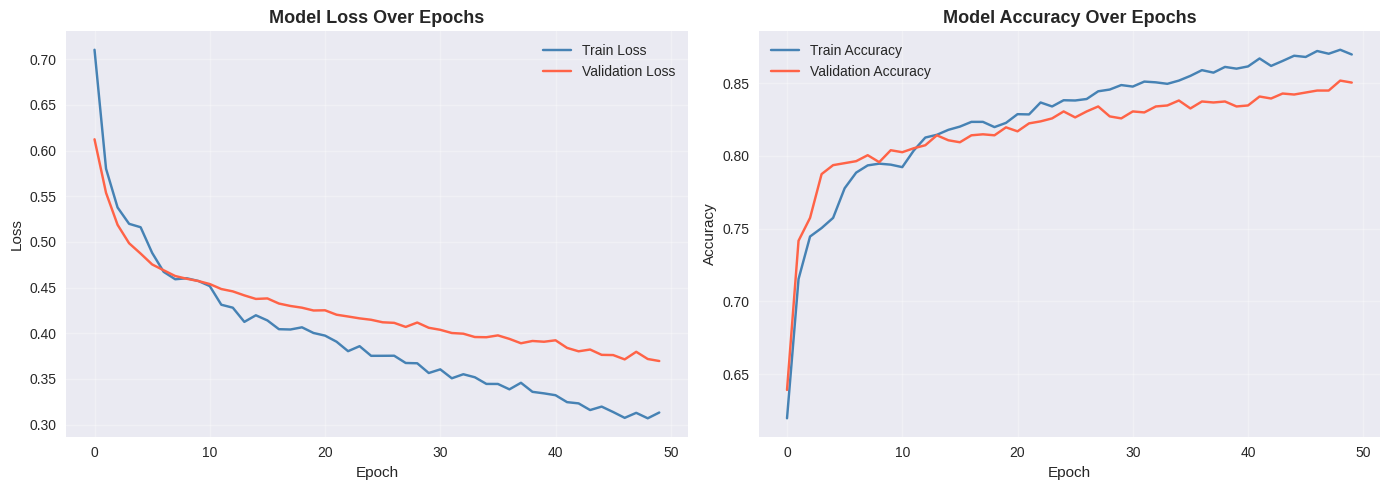

In [15]:
# Plot Training & Validation Loss / Accuracy
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history.history['loss'],     label='Train Loss',      color='steelblue')
axes[0].plot(history.history['val_loss'], label='Validation Loss', color='tomato')
axes[0].set_title('Model Loss Over Epochs', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='tomato')
axes[1].set_title('Model Accuracy Over Epochs', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Step 8: Calculate Sensitivity as a Metric

**Sensitivity (Recall / True Positive Rate)** measures the proportion of actual defaulters correctly identified.  
In loan default prediction, this is critical — missing a defaulter is costly.

$$ \text{Sensitivity} = \frac{TP}{TP + FN} $$

In [16]:
# Predict on test set
y_pred_proba = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

print('=== Confusion Matrix ===')
print(f'True Negatives  (TN): {TN:,}')
print(f'False Positives (FP): {FP:,}')
print(f'False Negatives (FN): {FN:,}')
print(f'True Positives  (TP): {TP:,}')

# Sensitivity (Recall)
sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)
precision   = TP / (TP + FP)
f1_score_val = 2 * (precision * sensitivity) / (precision + sensitivity)

print('\n=== Metrics ===')
print(f'Sensitivity (Recall)  : {sensitivity:.4f}  ({sensitivity*100:.2f}%)')
print(f'Specificity           : {specificity:.4f}  ({specificity*100:.2f}%)')
print(f'Precision             : {precision:.4f}  ({precision*100:.2f}%)')
print(f'F1-Score              : {f1_score_val:.4f}')
print()

print('=== Full Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Payer (0)', 'Defaulter (1)']))

58/58 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
=== Confusion Matrix ===
True Negatives  (TN): 760
False Positives (FP): 155
False Negatives (FN): 86
True Positives  (TP): 828

=== Metrics ===
Sensitivity (Recall)  : 0.9059  (90.59%)
Specificity           : 0.8306  (83.06%)
Precision             : 0.8423  (84.23%)
F1-Score              : 0.8730

=== Full Classification Report ===
               precision    recall  f1-score   support

    Payer (0)       0.90      0.83      0.86       915
Defaulter (1)       0.84      0.91      0.87       914

     accuracy                           0.87      1829
    macro avg       0.87      0.87      0.87      1829
 weighted avg       0.87      0.87      0.87      1829



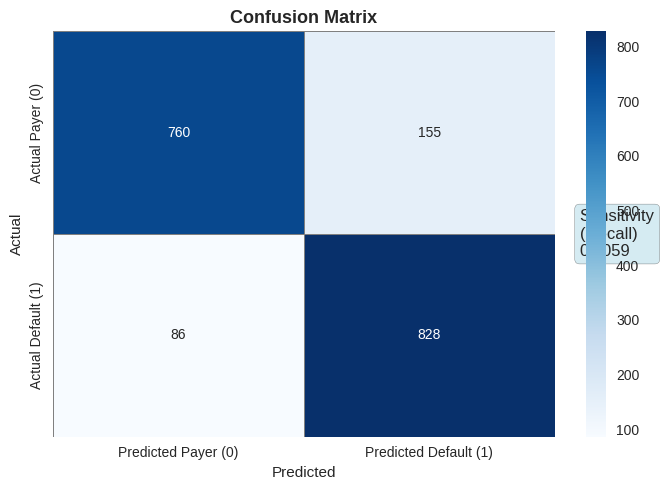

In [17]:
# Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt=',d', cmap='Blues',
    xticklabels=['Predicted Payer (0)', 'Predicted Default (1)'],
    yticklabels=['Actual Payer (0)', 'Actual Default (1)'],
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')

# Annotate with metric
ax.text(1.05, 0.5, f'Sensitivity\n(Recall)\n{sensitivity:.4f}',
        transform=ax.transAxes, fontsize=12, va='center',
        bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

plt.tight_layout()
plt.show()

## Step 8: Area Under the ROC Curve (AUC-ROC)

The **ROC curve** plots the True Positive Rate (Sensitivity) vs False Positive Rate at various thresholds.  
The **AUC** (Area Under the Curve) summarizes the model's discriminative ability.  
- AUC = 1.0 → perfect classifier
- AUC = 0.5 → random classifier

AUC-ROC Score: 0.9340
Optimal Threshold (Youden J): 0.5625
  Sensitivity at optimal threshold: 0.8961
  Specificity at optimal threshold: 0.8503


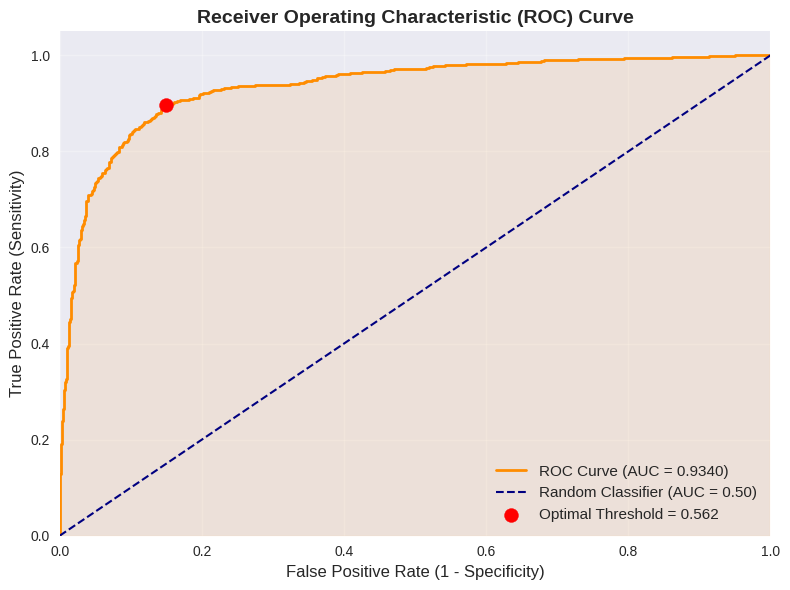

In [18]:
# Calculate AUC-ROC
auc_score = roc_auc_score(y_test, y_pred_proba)
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

print(f'AUC-ROC Score: {auc_score:.4f}')

# Find optimal threshold (Youden's J statistic)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = thresholds[optimal_idx]
print(f'Optimal Threshold (Youden J): {optimal_threshold:.4f}')
print(f'  Sensitivity at optimal threshold: {tpr[optimal_idx]:.4f}')
print(f'  Specificity at optimal threshold: {1 - fpr[optimal_idx]:.4f}')

# Plot ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(fpr, tpr, color='darkorange', lw=2,
        label=f'ROC Curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier (AUC = 0.50)')

# Mark optimal threshold
ax.scatter(
    fpr[optimal_idx], tpr[optimal_idx],
    color='red', s=100, zorder=5,
    label=f'Optimal Threshold = {optimal_threshold:.3f}'
)

ax.fill_between(fpr, tpr, alpha=0.1, color='darkorange')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('Receiver Operating Characteristic (ROC) Curve', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary of Results

In [19]:
print('=' * 55)
print('       HOME LOAN DEFAULT PREDICTION — RESULTS SUMMARY')
print('=' * 55)
print(f'  Dataset size (original)      : {len(df):,} records')
print(f'  Dataset size (after SMOTE)   : {len(y_balanced):,} records')
print(f'  Number of features           : {n_features}')
print(f'  Model architecture           : 128 → 64 → 32 → 1 (sigmoid)')
print()
print(f'  Sensitivity (Recall)         : {sensitivity:.4f}  ({sensitivity*100:.2f}%)')
print(f'  Specificity                  : {specificity:.4f}  ({specificity*100:.2f}%)')
print(f'  Precision                    : {precision:.4f}  ({precision*100:.2f}%)')
print(f'  F1-Score                     : {f1_score_val:.4f}')
print(f'  AUC-ROC Score                : {auc_score:.4f}')
print('=' * 55)

# Interpretation
print('\n📌 Interpretation:')
print(f'   • Sensitivity of {sensitivity*100:.1f}% means the model correctly identifies')
print(f'     {sensitivity*100:.1f}% of actual loan defaulters.')
print(f'   • AUC-ROC of {auc_score:.4f} indicates the model has a')
if auc_score >= 0.90:
    print('     EXCELLENT discriminative ability between payers and defaulters.')
elif auc_score >= 0.80:
    print('     GOOD discriminative ability between payers and defaulters.')
elif auc_score >= 0.70:
    print('     FAIR discriminative ability between payers and defaulters.')
else:
    print('     POOR discriminative ability — consider model improvements.')
print(f'   • SMOTE successfully balanced the dataset from an imbalanced state.')

       HOME LOAN DEFAULT PREDICTION — RESULTS SUMMARY
  Dataset size (original)      : 5,000 records
  Dataset size (after SMOTE)   : 9,144 records
  Number of features           : 26
  Model architecture           : 128 → 64 → 32 → 1 (sigmoid)

  Sensitivity (Recall)         : 0.9059  (90.59%)
  Specificity                  : 0.8306  (83.06%)
  Precision                    : 0.8423  (84.23%)
  F1-Score                     : 0.8730
  AUC-ROC Score                : 0.9340

📌 Interpretation:
   • Sensitivity of 90.6% means the model correctly identifies
     90.6% of actual loan defaulters.
   • AUC-ROC of 0.9340 indicates the model has a
     EXCELLENT discriminative ability between payers and defaulters.
   • SMOTE successfully balanced the dataset from an imbalanced state.
